京都の気象データ分析
目的

Open-Meteo APIから京都の気象データを取得し、
気温・降水量・風速などの変化を分析する。

データソース

Open-Meteo API

In [4]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 35.0116,
    "longitude": 135.7681,
    "start_date": "2025-01-01",
    "end_date": "2025-12-31",
    "daily": [
        "temperature_2m_mean",
        "precipitation_sum",
        "wind_speed_10m_max"
    ],
    "timezone": "Asia/Tokyo"
}

In [6]:
response = requests.get(url, params=params)

In [7]:
response.status_code

200

In [8]:
data = response.json()

data

{'latitude': 34.973637,
 'longitude': 135.74333,
 'generationtime_ms': 2.9075145721435547,
 'utc_offset_seconds': 32400,
 'timezone': 'Asia/Tokyo',
 'timezone_abbreviation': 'GMT+9',
 'elevation': 51.0,
 'daily_units': {'time': 'iso8601',
  'temperature_2m_mean': '°C',
  'precipitation_sum': 'mm',
  'wind_speed_10m_max': 'km/h'},
 'daily': {'time': ['2025-01-01',
   '2025-01-02',
   '2025-01-03',
   '2025-01-04',
   '2025-01-05',
   '2025-01-06',
   '2025-01-07',
   '2025-01-08',
   '2025-01-09',
   '2025-01-10',
   '2025-01-11',
   '2025-01-12',
   '2025-01-13',
   '2025-01-14',
   '2025-01-15',
   '2025-01-16',
   '2025-01-17',
   '2025-01-18',
   '2025-01-19',
   '2025-01-20',
   '2025-01-21',
   '2025-01-22',
   '2025-01-23',
   '2025-01-24',
   '2025-01-25',
   '2025-01-26',
   '2025-01-27',
   '2025-01-28',
   '2025-01-29',
   '2025-01-30',
   '2025-01-31',
   '2025-02-01',
   '2025-02-02',
   '2025-02-03',
   '2025-02-04',
   '2025-02-05',
   '2025-02-06',
   '2025-02-07',
   '2

In [9]:
daily = data["daily"]

daily

{'time': ['2025-01-01',
  '2025-01-02',
  '2025-01-03',
  '2025-01-04',
  '2025-01-05',
  '2025-01-06',
  '2025-01-07',
  '2025-01-08',
  '2025-01-09',
  '2025-01-10',
  '2025-01-11',
  '2025-01-12',
  '2025-01-13',
  '2025-01-14',
  '2025-01-15',
  '2025-01-16',
  '2025-01-17',
  '2025-01-18',
  '2025-01-19',
  '2025-01-20',
  '2025-01-21',
  '2025-01-22',
  '2025-01-23',
  '2025-01-24',
  '2025-01-25',
  '2025-01-26',
  '2025-01-27',
  '2025-01-28',
  '2025-01-29',
  '2025-01-30',
  '2025-01-31',
  '2025-02-01',
  '2025-02-02',
  '2025-02-03',
  '2025-02-04',
  '2025-02-05',
  '2025-02-06',
  '2025-02-07',
  '2025-02-08',
  '2025-02-09',
  '2025-02-10',
  '2025-02-11',
  '2025-02-12',
  '2025-02-13',
  '2025-02-14',
  '2025-02-15',
  '2025-02-16',
  '2025-02-17',
  '2025-02-18',
  '2025-02-19',
  '2025-02-20',
  '2025-02-21',
  '2025-02-22',
  '2025-02-23',
  '2025-02-24',
  '2025-02-25',
  '2025-02-26',
  '2025-02-27',
  '2025-02-28',
  '2025-03-01',
  '2025-03-02',
  '2025-03-03',


In [10]:
df = pd.DataFrame(daily)

df.head()

,time,temperature_2m_mean,precipitation_sum,wind_speed_10m_max
0,2025-01-01,3.8,0.0,11.7
1,2025-01-02,3.8,0.0,9.2
2,2025-01-03,4.4,1.0,17.5
3,2025-01-04,3.3,0.0,13.7
4,2025-01-05,2.6,0.0,8.6


In [11]:
df = df.rename(columns={
    "time": "date",
    "temperature_2m_mean": "temperature",
    "precipitation_sum": "precipitation",
    "wind_speed_10m_max": "wind_speed"
})

df.head()

,date,temperature,precipitation,wind_speed
0,2025-01-01,3.8,0.0,11.7
1,2025-01-02,3.8,0.0,9.2
2,2025-01-03,4.4,1.0,17.5
3,2025-01-04,3.3,0.0,13.7
4,2025-01-05,2.6,0.0,8.6


In [12]:
df["date"] = pd.to_datetime(df["date"])

df.dtypes

date             datetime64[ns]
temperature             float64
precipitation           float64
wind_speed              float64
dtype: object

In [13]:
df.shape

(365, 4)

In [14]:
df.columns

Index(['date', 'temperature', 'precipitation', 'wind_speed'], dtype='object')

In [15]:
df.isnull().sum()

date             0
temperature      0
precipitation    0
wind_speed       0
dtype: int64

In [16]:
df["date"].duplicated().sum()

np.int64(0)

In [17]:
df[["temperature","precipitation","wind_speed"]].describe()

,temperature,precipitation,wind_speed
count,365.000000,365.000000,365.000000
mean,16.000000,3.951507,12.551507
std,9.610217,8.879265,4.300534
min,-0.500000,0.000000,4.700000
25%,7.200000,0.000000,9.100000
50%,15.100000,0.200000,11.900000
75%,25.100000,3.300000,15.000000
max,32.300000,75.400000,25.300000


In [18]:
df["month"]=df["date"].dt.month

df.head()

,date,temperature,precipitation,wind_speed,month
0,2025-01-01,3.8,0.0,11.7,1
1,2025-01-02,3.8,0.0,9.2,1
2,2025-01-03,4.4,1.0,17.5,1
3,2025-01-04,3.3,0.0,13.7,1
4,2025-01-05,2.6,0.0,8.6,1


In [19]:
monthly_temp = df.groupby("month")["temperature"].mean()

monthly_temp

month
1      3.519355
2      2.792857
3      8.445161
4     13.620000
5     18.277419
6     23.500000
7     29.116129
8     29.283871
9     25.923333
10    19.045161
11    10.906667
12     6.612903
Name: temperature, dtype: float64

In [20]:
monthly_rain = df.groupby("month")["precipitation"].mean()

monthly_rain

month
1     0.706452
2     1.053571
3     3.222581
4     2.746667
5     7.032258
6     9.473333
7     4.461290
8     4.135484
9     6.246667
10    4.900000
11    1.320000
12    1.967742
Name: precipitation, dtype: float64

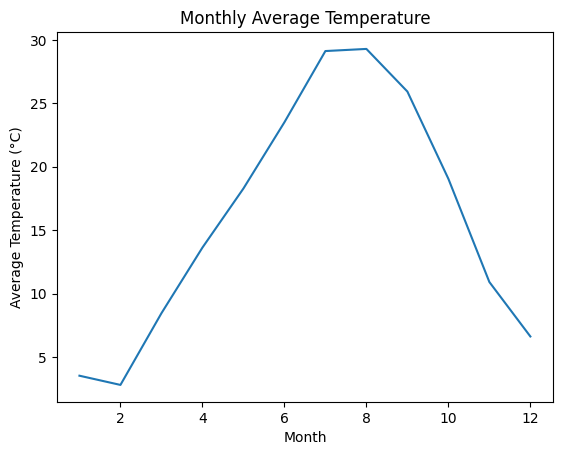

In [21]:
import matplotlib.pyplot as plt

plt.plot(monthly_temp.index,monthly_temp.values)

plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.title("Monthly Average Temperature")

plt.show()

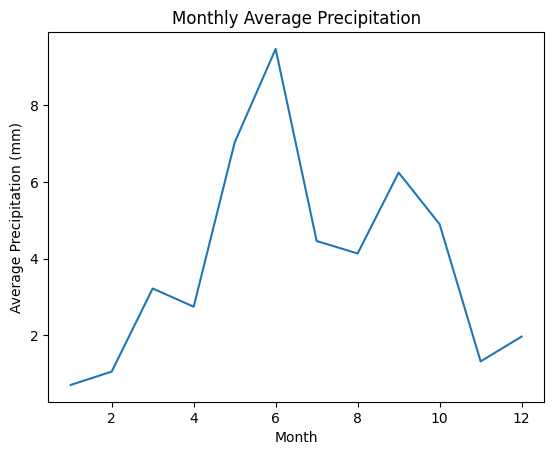

In [22]:
plt.plot(monthly_rain.index, monthly_rain.values)

plt.xlabel("Month")
plt.ylabel("Average Precipitation (mm)")
plt.title("Monthly Average Precipitation")

plt.show()

In [23]:
monthly = pd.DataFrame({
    "temperature": monthly_temp,
    "precipitation": monthly_rain
})

monthly

,temperature,precipitation
month,,
1,3.519355,0.706452
2,2.792857,1.053571
3,8.445161,3.222581
4,13.620000,2.746667
5,18.277419,7.032258
6,23.500000,9.473333
7,29.116129,4.461290
8,29.283871,4.135484
9,25.923333,6.246667


In [24]:
monthly["temperature"].corr(monthly["precipitation"])

np.float64(0.7149325867944737)

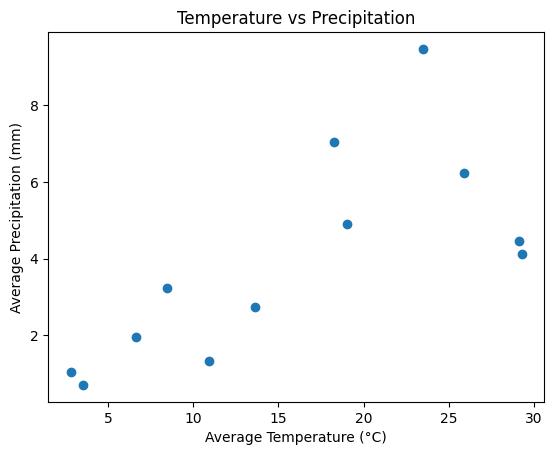

In [25]:
plt.scatter(monthly["temperature"],monthly["precipitation"])

plt.xlabel("Average Temperature (°C)")
plt.ylabel("Average Precipitation (mm)")
plt.title("Temperature vs Precipitation")

plt.show()

In [26]:
monthly_wind = df.groupby("month")["wind_speed"].max()

monthly_wind

month
1     23.0
2     25.3
3     24.6
4     24.7
5     22.8
6     19.1
7     21.7
8     19.0
9     19.5
10    16.3
11    20.9
12    21.3
Name: wind_speed, dtype: float64

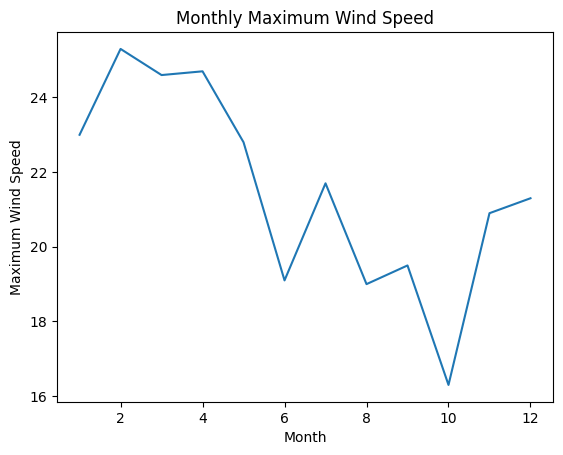

In [47]:
plt.plot(monthly_wind.index, monthly_wind.values)

plt.xlabel("Month")
plt.ylabel("Maximum Wind Speed")
plt.title("Monthly Maximum Wind Speed")

plt.savefig("../images/monthly_wind_speed.png")

plt.show()

In [28]:
df.to_csv("../data/kyoto_weather_2025.csv", index=False)

In [29]:
df_check = pd.read_csv("../data/kyoto_weather_2025.csv")

df_check.head()

,date,temperature,precipitation,wind_speed,month
0,2025-01-01,3.8,0.0,11.7,1
1,2025-01-02,3.8,0.0,9.2,1
2,2025-01-03,4.4,1.0,17.5,1
3,2025-01-04,3.3,0.0,13.7,1
4,2025-01-05,2.6,0.0,8.6,1


In [30]:
df_check.dtypes

date              object
temperature      float64
precipitation    float64
wind_speed       float64
month              int64
dtype: object

In [31]:
df_check["date"] = pd.to_datetime(df_check["date"])

df_check.dtypes

date             datetime64[ns]
temperature             float64
precipitation           float64
wind_speed              float64
month                     int64
dtype: object

In [32]:
df_check.shape

(365, 5)

In [33]:
monthly_summary = df.groupby("month").agg(
    avg_temperature=("temperature", "mean"),
    avg_precipitation=("precipitation", "mean"),
    max_wind_speed=("wind_speed", "max")
)

monthly_summary

,avg_temperature,avg_precipitation,max_wind_speed
month,,,
1,3.519355,0.706452,23.0
2,2.792857,1.053571,25.3
3,8.445161,3.222581,24.6
4,13.620000,2.746667,24.7
5,18.277419,7.032258,22.8
6,23.500000,9.473333,19.1
7,29.116129,4.461290,21.7
8,29.283871,4.135484,19.0
9,25.923333,6.246667,19.5


In [34]:
monthly_summary["avg_temperature"].idxmax()

np.int32(8)

In [35]:
monthly_summary["avg_temperature"].max()

np.float64(29.283870967741933)

In [36]:
monthly_summary["avg_temperature"].idxmin()

np.int32(2)

In [37]:
monthly_summary["avg_precipitation"].idxmax()

np.int32(6)

In [38]:
monthly_summary["avg_precipitation"].max()

np.float64(9.473333333333333)

In [39]:
monthly_summary["max_wind_speed"].idxmax()

np.int32(2)

In [40]:
monthly_summary["max_wind_speed"].max()

np.float64(25.3)

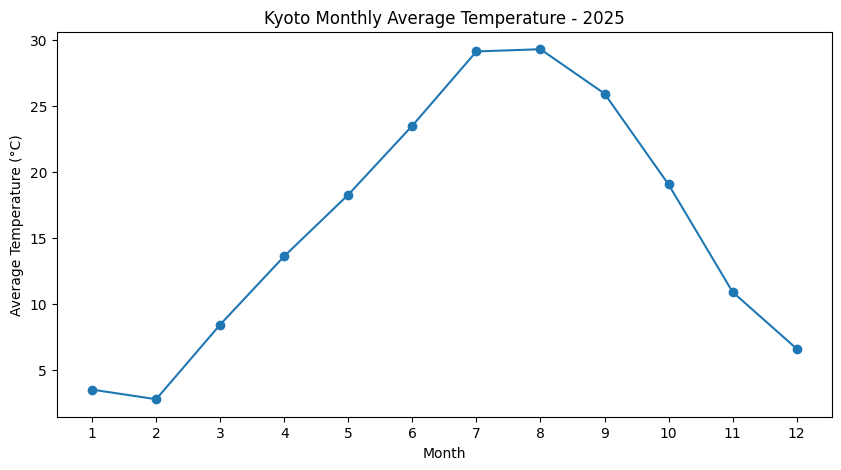

In [41]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_summary.index,
    monthly_summary["avg_temperature"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.title("Kyoto Monthly Average Temperature - 2025")

plt.xticks(range(1, 13))

plt.savefig("../images/monthly_temperature.png")

plt.show()

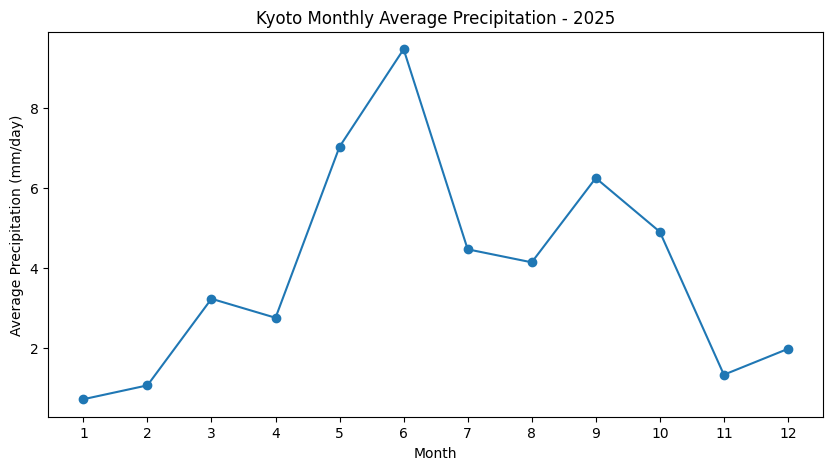

In [46]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_summary.index,
    monthly_summary["avg_precipitation"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Precipitation (mm/day)")
plt.title("Kyoto Monthly Average Precipitation - 2025")

plt.xticks(range(1, 13))

plt.savefig("../images/monthly_precipitation.png")

plt.show()

([<matplotlib.axis.XTick at 0x1b4f6ac52a0>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12')])

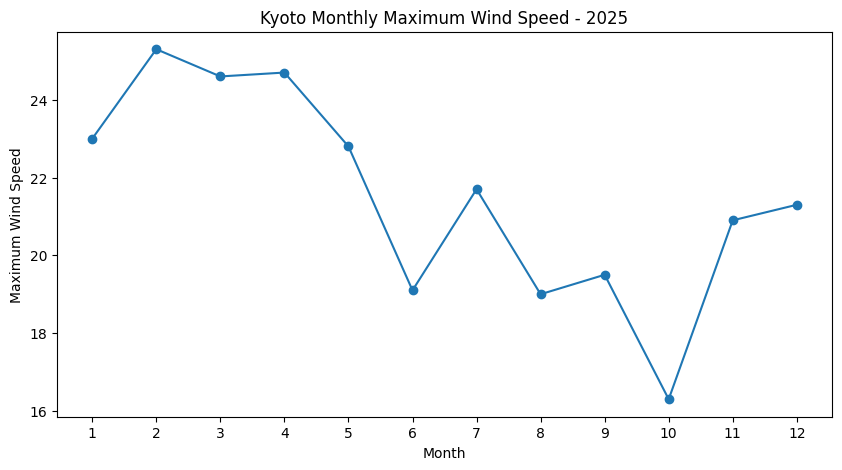

In [43]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_summary.index,
    monthly_summary["max_wind_speed"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Maximum Wind Speed")
plt.title("Kyoto Monthly Maximum Wind Speed - 2025")

plt.xticks(range(1, 13))


## 分析結果

- 2025年の月平均気温は8月が最も高く、約29.28℃だった。
- 月平均気温は2月が最も低く、約2.79℃だった。
- 月平均降水量は6月が最も高く、約9.47 mm/日だった。
- 月間最大風速は2月が最も高く、25.3だった。
- 気温は春から夏にかけて上昇し、8月をピークに秋から冬にかけて低下する傾向が見られた。

## 相関についての考察

月別の平均気温と平均降水量の相関係数は約0.71だった。

今回の2025年の京都の月別データでは、
気温が高い月ほど平均降水量も多くなる傾向が見られた。

ただし、相関関係があることだけでは、
「気温が高くなることで降水量が増える」とは判断できない。

今回の分析では12か月分のデータを使用しているため、
より長期間のデータや他の気象要因も含めて分析することで、
より詳しく関係を調べることができる。

In [44]:
monthly_summary.to_csv("../data/kyoto_weather_monthly_summary.csv")

In [45]:
monthly_check = pd.read_csv(
    "../data/kyoto_weather_monthly_summary.csv",
    index_col=0
)

monthly_check

,avg_temperature,avg_precipitation,max_wind_speed
month,,,
1,3.519355,0.706452,23.0
2,2.792857,1.053571,25.3
3,8.445161,3.222581,24.6
4,13.620000,2.746667,24.7
5,18.277419,7.032258,22.8
6,23.500000,9.473333,19.1
7,29.116129,4.461290,21.7
8,29.283871,4.135484,19.0
9,25.923333,6.246667,19.5


## 分析方法

1. Open-Meteo APIから2025年の京都の気象データを取得
2. JSONデータをPandasのDataFrameに変換
3. 日付をdatetime型に変換
4. 欠損値と重複データを確認
5. 月別に平均気温・平均降水量・最大風速を集計
6. Matplotlibを使用して月別推移を可視化
7. 相関係数を計算し、気温と降水量の関係を分析
8. 分析結果をCSVとして保存